# S2 Coursework DRAFT

## Question 1: Accident data

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [76]:
mining_data = np.loadtxt(os.path.join('data','coal_mining_accident_data.dat'))
flattened_data = np.ndarray.flatten(mining_data, order="C")
flattened_data_cumulative = np.copy(flattened_data)

total_period = 40550
total_events = 191

for i in range(len(flattened_data)-1):
    flattened_data_cumulative[i+1:] += flattened_data[i]
number_of_accidents = np.arange(0, len(flattened_data_cumulative), 1)

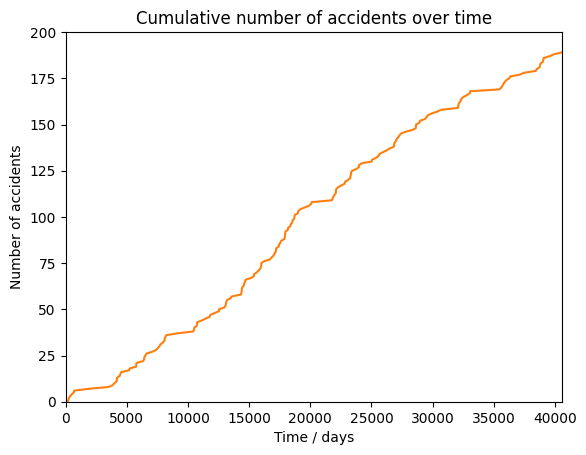

In [77]:
plt.plot(flattened_data_cumulative, number_of_accidents, color="tab:orange")
plt.xlabel("Time / days")
plt.ylabel("Number of accidents")
plt.title("Cumulative number of accidents over time")
plt.xlim(0,40550)
plt.ylim(0,200)
plt.show()

In [70]:
mean_rate = total_events / (total_period)
print(f"Mean rate of accidents: {mean_rate:.4f} per day")
mean_rate_year = number_of_accidents[-1] / (total_period / 365) # Convert total period from years to days
print(f"Mean rate of accidents: {mean_rate_year:.2f} per year")

Mean rate of accidents: 0.0047 per day
Mean rate of accidents: 1.70 per year


## Question 2: Priors

### (a)

(4,)
[ 7367.93469186 17075.0301389  24672.1010175  31206.43463331]
(4,)
[ 6792.65968848 18348.45500838 25851.74155904 36849.48405664]


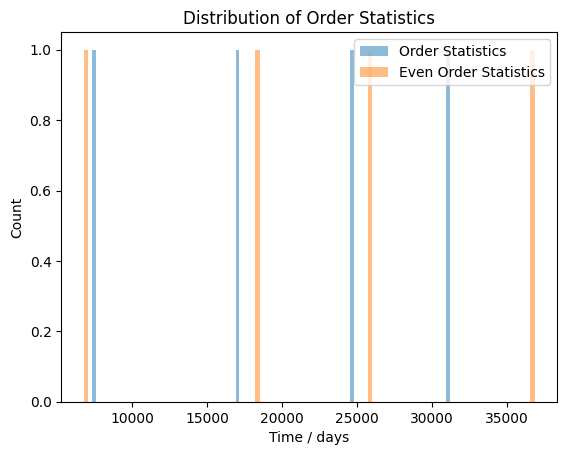

In [71]:
from scipy import special

def gamma(x, alpha, beta):
    pdf = (beta ** alpha) * np.exp(-beta * x) / special.gamma(alpha)
    return pdf

k = 4
order_statistics = np.sort(np.random.uniform(0, total_period, k))
print(np.shape(order_statistics))
print(order_statistics)
even_order_statistics = np.sort(np.random.uniform(0, total_period, 2 * k + 1))[1:-1:2]
print(np.shape(even_order_statistics))
print(even_order_statistics)

plt.hist(order_statistics, bins=100, density=False, alpha=0.5, label='Order Statistics')
plt.hist(even_order_statistics, bins=100, density=False, alpha=0.5, label='Even Order Statistics')
plt.xlabel("Time / days")
plt.ylabel("Count")
plt.title("Distribution of Order Statistics")
plt.legend()
plt.show()

## Question 3: The constant rate model

### (a)

The prior on $h_0$ is 

\begin{equation}
    \pi(h_0|M_0)=\beta^\alpha\exp(-\beta h)/\Gamma(\alpha),
\end{equation}

where $\alpha=1$, $\beta=200\;\text{days}$. In the constant rate case, the log-likelihood is simply

\begin{equation}
    \log\mathcal{L}(\{I_i\}|h_0,M_0)=N\log h_0-h_0L.
\end{equation}

The posterior on $h_0$ is thus

\begin{equation}
    P(h_0|\{I_i\}, M_0)=200h_0^N\exp(-h_0(200+L)).
\end{equation}

In [72]:
alpha = 1
beta = 200

def constant_rate_prior(h, alpha, beta):
    return beta ** alpha * np.exp(-beta * h) / special.gamma(alpha)

def log_constant_rate_prior(h, alpha, beta):
    return alpha * np.log(beta) - beta * h - special.gammaln(alpha)

def constant_rate_likelihood(h):
    return h ** total_events * np.exp(-h * total_period)

def log_constant_rate_likelihood(h):
    return total_events * np.log(h) - h * total_period

def constant_rate_posterior(h, alpha, beta):
    return constant_rate_prior(h, alpha, beta) * constant_rate_likelihood(h) * model_prior(0)

def log_constant_rate_posterior(h, alpha, beta):
    return log_constant_rate_prior(h, alpha, beta) + log_constant_rate_likelihood(h) + np.log(model_prior(0))

/tmp/ipykernel_2709/201432118.py:14: RuntimeWarning: divide by zero encountered in log
  return total_events * np.log(h) - h * total_period


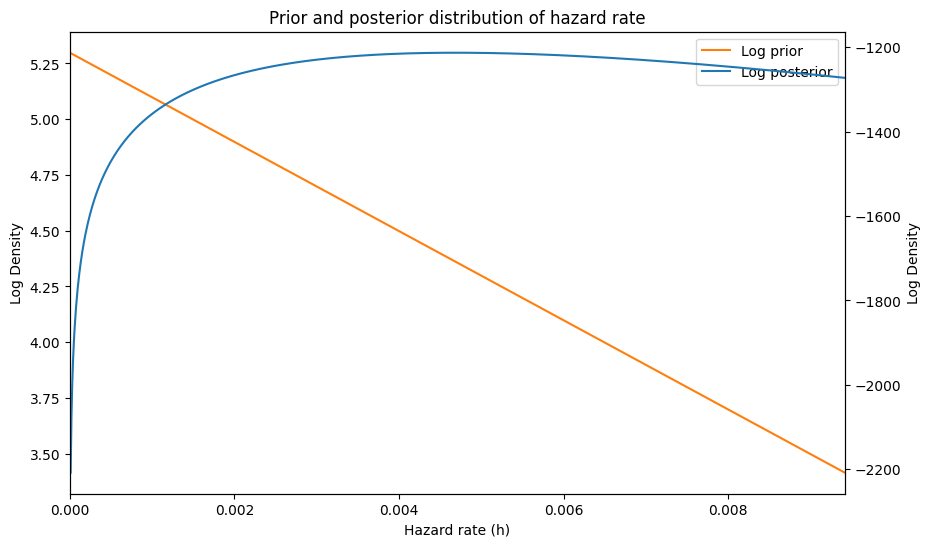

In [73]:
h_values = np.linspace(0, 191 * 2 / 40550, 1000)
log_posterior_values = log_constant_rate_posterior(h_values, alpha, beta)
log_prior_values = log_constant_rate_prior(h_values, alpha, beta)

fig, ax = plt.subplots(figsize=(10, 6))
ax2 = ax.twinx()
p1 = ax.plot(h_values, log_prior_values, color="tab:orange", label="Log prior")
p2 = ax2.plot(h_values, log_posterior_values, color="tab:blue", label="Log posterior")

ax.set_xlabel("Hazard rate (h)")
ax.set_ylabel("Log Density")
ax.set_title("Prior and posterior distribution of hazard rate")
ax.set_xlim(0, 191 * 2 / 40550)
ax2.set_ylabel("Log Density")

ps = p1 + p2
labels = [p.get_label() for p in ps]
ax.legend(ps, labels, loc=0)

plt.show()

Computing the evidence from the unnormalised posterior requires scaling the integrand by a constant to avoid underflow errors. The evidence is given by

\begin{equation}
    Z=\int_0^\infty 200h_0^N\exp(-h_0(200+L))dh_0.
\end{equation}

We can compute the maximum of the log-integrand, which turns out to be at $h_0=\frac{N}{200+L}$. Subtracting the log-integrand evaluated at this point we get

\begin{equation}
    \log\tilde{P}=\log P+\text{const}=N(\log\frac{h_0(200+L)}{N}+1)-h_0(200+L),
\end{equation}

where $\text{const}=\log(200(\frac{N}{200+L})^N)\exp(-N)$. With this, the evidence is given by

\begin{equation}
    Z=\exp(-\text{const})\int\exp\tilde{P}dh_0.
\end{equation}

In [74]:
from scipy.integrate import quad

def exp_scaled_log_integrand(h):
    return np.exp(total_events * (np.log(h * (200 + total_period)/total_events) + 1) - h * (200 + total_period))

scaled_evidence, _ = quad(exp_scaled_log_integrand, 0, 1)
print(f"Scaled evidence: {scaled_evidence:.10e}")

Scaled evidence: 8.5048858166e-04


The prefactor in the evidence $\exp(\text{const})$ is tiny. With the given parameters, it evaluates to

\begin{equation}
    200\biggl(\frac{191}{40750}\biggr)^{191}\exp(-191) = 3.12\times10^{-526}.
\end{equation}

As a result, the total evidence is

\begin{equation}
    Z=2.65\times10^{-529},
\end{equation}

\begin{equation}
    \log Z=-1217.09.
\end{equation}

## Question 4: The 1 change point model

### (a)

I have used the package `emcee` which use the affine-invariant Markov Chain Monte Carlo ensemble sampler algorithm.

In [ ]:
import emcee



## References

1. [emcee ReadTheDocs](https://emcee.readthedocs.io/en/stable/)
2. [Ensemble samplers with affine invariance (Goodman and Weare)](https://msp.org/camcos/2010/5-1/p04.xhtml)